## Explainability Analysis of a Chess Position Classification Neural Network
**Student:** Artem Okhten  
**Course:** MTH 4326 - Explainable AI  
**Term:** Spring 2026

## Abstract

In this project I study counterfactual explanations for convolutional neural network that classifies chess positions. The model predicts one of three classes: Black-better, Draw/Equal, or White-better. Dataset comes from Lichess PGN games. For each game, I extract one position after 20 full moves and convert board into 13x8x8 tensor. The tensor has 12 channels for pieces and one channel for whose turn it is. Labels are made using Stockfish evaluations, not final game results, because I want model to learn quality of current position.

The goal is not to build strongest chess engine. The CNN is used as model that can be explained. First, I use gradient saliency map as baseline explanation method. This shows which squares model is locally sensitive to. Then I use counterfactual search to test what small board changes are enough to change model prediction. The main counterfactual method removes one non-king piece at a time. I measure size of change using material distance and number of changed squares.

The CNN reached 63.73% test accuracy, compared with 44.60% majority-class baseline on test set. This means model learned some chess evaluation structure, even though it is not perfect evaluator. In counterfactual experiment, one-piece removal changed model prediction in 76.20% of sampled test positions. Many successful counterfactuals came from low-material pieces, especially pawns. This suggests that model decision boundary is often close to original position. Overall, counterfactual explanations give another way to inspect model beyond accuracy and saliency maps.

## Research Questions

This project is based on three questions:

1. Can small CNN trained on chess position tensors learn enough structure to be useful for explanation?
2. Do gradient saliency maps and counterfactual explanations show different parts of model behavior?
3. How stable are model predictions when small piece-removal changes are made?

These questions matter because explainability is not only about making a heatmap. Useful explanation should also test whether changing input actually changes model decision.

## 1. Introduction and Motivation

In this project I analyze counterfactual explanations for neural network that classifies chess positions. Instead of only asking which squares or pieces are important, I ask what small change to position is enough to change model prediction.

This project uses chess data, but it is different from my Intro to Machine Learning project. In that project, focus was mainly on building or comparing machine learning models. Here, model is not final goal. The classifier is used as object being explained. Main focus is explanation validity, counterfactual distance, and stability of model decisions.

The model is also not intended to be strongest chess engine. It is CNN trained on board tensors so that its predictions can be inspected. I want to understand where its decision boundaries are and whether counterfactual changes make chess sense, for example material balance, dependence on individual pieces, or positional structure.

## 2. Dataset and Model

The dataset consists of chess positions extracted after fixed number of moves. Each position is represented as a $13 \times 8 \times 8$ tensor:

- **12 piece channels:** White and Black pawns, knights, bishops, rooks, queens, and kings.
- **1 turn channel:** shows whose turn it is to move.

The labels are based on Stockfish evaluation of the position:

- **Class 0 (Black better):** Evaluation < -1.0
- **Class 1 (Equal / balanced):** -1.0 <= Evaluation <= +1.0
- **Class 2 (White better):** Evaluation > +1.0

I used Stockfish with short time limit, 0.1 seconds per position, to keep preprocessing possible on my computer. Because of this, the labels should be understood as approximate engine labels, not full deep Stockfish analysis.

The dataset is parsed directly from `lichess_data.pgn`. During parsing, each selected board position is converted into tensor representation and then used for model training.

For the final experiment, we used 10,000 positions extracted from Lichess PGN games. This matches the scale from the proposal and is still manageable for local training. The positions are extracted after 20 full moves, so the model looks at early middlegame structure instead of final game result.

In the code, `max_plies=40` means that position is extracted after 20 full moves. One ply is a half-move, so 40 plies means White and Black both made 20 moves.

After the dataset is prepared, we train a simple Convolutional Neural Network (CNN) to classify these positions. The CNN is not meant to be strongest evaluator. It is used as model that will later be explained with saliency and counterfactual methods.

In [1]:
import os
import sys
import time
import asyncio
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import chess
import chess.pgn
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import display
import warnings

# windows fix for python-chess and Stockfish subprocess
if sys.platform == "win32":
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

# set seed for reproducibility
torch.manual_seed(11)
np.random.seed(11)
random.seed(11)

sns.set_theme(style="whitegrid")

# Use CPU
device = torch.device("cpu")

In [2]:
def board_to_tensor(board):
    """Converts a chess.Board into a 13x8x8 spatial tensor"""
    tensor = np.zeros((13, 8, 8), dtype=np.float32)
    for square, piece in board.piece_map().items():
        # store rank 8 as row 0 and rank 1 as row 7 to match normal board view
        row = 7 - chess.square_rank(square)
        col = chess.square_file(square)
        piece_type = piece.piece_type - 1
        color_offset = 0 if piece.color == chess.WHITE else 6
        channel = piece_type + color_offset
        tensor[channel, row, col] = 1.0
        
    # 13th channel is 1.0 if White's turn and 0.0 if Black's turn
    if board.turn == chess.WHITE:
        tensor[12, :, :] = 1.0
        
    return tensor

def load_lichess_dataset(filepath='lichess_data.pgn', num_positions=10000, max_plies=40, engine_path='stockfish'):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File {filepath} not found")
        
    print(f"Processing PGN games from {filepath}")
    tensors, labels = [], []
    start_time = time.time()
    
    try:
        import chess.engine
        print(f"Attempting to start Stockfish at path '{engine_path}'")
        engine = chess.engine.SimpleEngine.popen_uci(engine_path)
        print("Stockfish engine initialized successfully.")
    except FileNotFoundError as e:
        raise RuntimeError(
            f"Stockfish engine was not found'.\n"
        ) from e
    except Exception as e:
        raise RuntimeError(f"Failed: {e}") from e

    with open(filepath, 'r', encoding='utf-8', errors='ignore') as pgn_file:
        while len(tensors) < num_positions:
            game = chess.pgn.read_game(pgn_file)
            if game is None:
                break 
                
            board = game.board()
            moves = list(game.mainline_moves())
            
            if len(moves) >= max_plies:
                for i, move in enumerate(moves):
                    board.push(move)
                    if i == max_plies - 1:
                        # evaluate with stockfish
                        info = engine.analyse(board, chess.engine.Limit(time=0.1))
                        score = info["score"].white()
                        
                        if score.is_mate():
                            eval_val = 10.0 if score.mate() > 0 else -10.0
                        else:
                            eval_val = score.score(mate_score=10000) / 100.0
                            
                        if eval_val < -1.0: label = 0
                        elif eval_val > 1.0: label = 2
                        else: label = 1
                        
                        tensors.append(board_to_tensor(board))
                        labels.append(label)
                        
                        # print progress every 100 games
                        if len(tensors) % 500 == 0:
                            elapsed = time.time() - start_time
                            print(f"Processed {len(tensors)} / {num_positions} positions ({elapsed:.2f}s)")
                        break
                        
    if engine is not None:
        engine.quit()
        
    return np.array(tensors), np.array(labels)

In [3]:
CACHE_X = "xai_chess_X_10000.npy"
CACHE_Y = "xai_chess_y_10000.npy"

if os.path.exists(CACHE_X) and os.path.exists(CACHE_Y):
    print("Loading cached processed tensors")
    X_data = np.load(CACHE_X)
    y_data = np.load(CACHE_Y)
else:
    ENGINE_PATH = r"C:\Users\darha\Documents\MTH 4326\project2\stockfish\stockfish.exe"
    
    X_data, y_data = load_lichess_dataset(
        'lichess_data.pgn',
        num_positions=10000,
        max_plies=40,
        engine_path=ENGINE_PATH
    )
    np.save(CACHE_X, X_data)
    np.save(CACHE_Y, y_data)

if len(y_data) == 0:
    raise ValueError("Failed")

class ChessDataset(Dataset):
    def __init__(self, tensors, labels):
        self.tensors = torch.tensor(tensors, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.tensors[idx], self.labels[idx]

full_dataset = ChessDataset(X_data, y_data)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, val_size, test_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Processing PGN games from lichess_data.pgn
Attempting to start Stockfish at path 'C:\Users\darha\Documents\MTH 4326\project2\stockfish\stockfish.exe'
Stockfish engine initialized successfully.
Processed 500 / 10000 positions (52.43s)
Processed 1000 / 10000 positions (104.72s)
Processed 1500 / 10000 positions (157.16s)
Processed 2000 / 10000 positions (210.29s)
Processed 2500 / 10000 positions (264.74s)
Processed 3000 / 10000 positions (317.56s)
Processed 3500 / 10000 positions (370.15s)
Processed 4000 / 10000 positions (423.45s)
Processed 4500 / 10000 positions (476.96s)
Processed 5000 / 10000 positions (531.17s)
Processed 5500 / 10000 positions (584.62s)
Processed 6000 / 10000 positions (637.73s)
Processed 6500 / 10000 positions (690.71s)
Processed 7000 / 10000 positions (743.34s)
Processed 7500 / 10000 positions (795.88s)
Processed 8000 / 10000 positions (848.34s)
Processed 8500 / 10000 positions (900.81s)
Processed 9000 / 10000 positions (953.40s)
Processed 9500 / 10000 positions (1

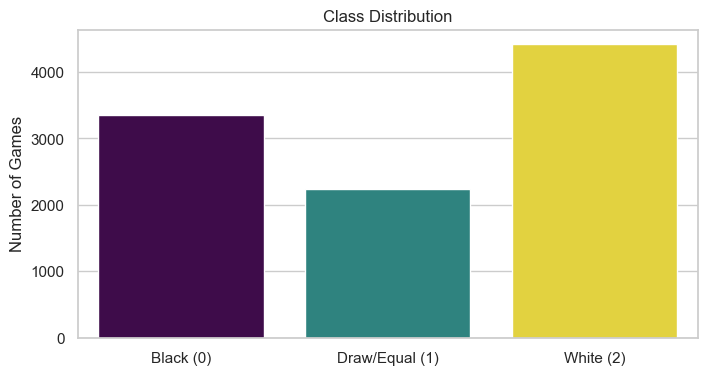

Total Data Points: 10000
Train: 7000, Val: 1500, Test: 1500

Majority Class Baseline (Entire Dataset): 44.15%

Train class counts: [2339 1561 3100]
Validation class counts: [509 345 646]
Test class counts: [498 333 669]


In [4]:
# basic dataset statistics
class_map = {0: 'Black', 1: 'Draw/Equal', 2: 'White'}
classes = ["Black (0)", "Draw/Equal (1)", "White (2)"]

plt.figure(figsize=(8, 4))
sns.countplot(x=y_data, hue=y_data, palette="viridis", legend=False)
plt.title("Class Distribution")
plt.xticks(ticks=[0, 1, 2], labels=classes)
plt.ylabel("Number of Games")
plt.show()

print(f"Total Data Points: {len(y_data)}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}\n")

majority_baseline = max(np.bincount(y_data, minlength=3)) / len(y_data)
print(f"Majority Class Baseline (Entire Dataset): {majority_baseline * 100:.2f}%\n")

def show_split_distribution(dataset, name):
    labels = [dataset[i][1].item() for i in range(len(dataset))]
    counts = np.bincount(labels, minlength=3)
    print(f"{name} class counts: {counts}")

show_split_distribution(train_dataset, "Train")
show_split_distribution(val_dataset, "Validation")
show_split_distribution(test_dataset, "Test")

### Dataset Distribution Interpretation

The final dataset contains 10,000 positions. Class distribution is not perfectly balanced: White-better positions appear most often, Black-better positions are second, and Draw/Equal positions appear less often. However, all three classes are still represented well in training, validation, and test sets.

The majority-class baseline for entire dataset is 44.15%. This is important because model should not be compared only to random guessing. It also should be compared to simple baseline that always predicts most common class. The majority-class baseline gives more realistic lower bound for model performance.

## Methodology Overview

The experiment follows five main steps:

1. **Position extraction:** Parse Lichess PGN games and extract one board position after 20 full moves.
2. **Label generation:** Evaluate each extracted position with Stockfish and assign it to Black-better, Draw/Equal, or White-better class.
3. **Model training:** Train small CNN on the 13x8x8 board tensors.
4. **Baseline explanation:** Use gradient saliency to see which board squares affect predicted class score.
5. **Counterfactual analysis:** Remove one non-king piece at a time and check if prediction changes.

The main evaluation is not only classification accuracy. Accuracy is used just to check that model learned some signal from data. After that, I also measure explanation validity, counterfactual distance, and stability across predicted classes.

## Experimental Design

The CNN is trained mainly to create a model that can be explained. Because of this, I do not tune the model very aggressively for maximum accuracy. Instead, I use small architecture that is easy to inspect and fast enough to train locally. This makes explanation analysis more important than predictive performance alone.

The counterfactual experiment is run on held-out test positions, not on training set. This is important because explanations should be tested on positions that model did not see directly during training. If counterfactuals are only tested on training data, then results can look better than they actually are.

In [5]:
# the goal is not to build a chess engine
# we just need a model whose decisions can be analyzed
class ChessCNN(nn.Module):
    def __init__(self):
        super(ChessCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(13, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = ChessCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Starting CNN training
Epoch 1/12, Loss: 1.0596, Val Acc: 47.07%
Epoch 2/12, Loss: 0.9946, Val Acc: 51.80%
Epoch 3/12, Loss: 0.9368, Val Acc: 56.07%
Epoch 4/12, Loss: 0.8869, Val Acc: 56.53%
Epoch 5/12, Loss: 0.8414, Val Acc: 53.27%
Epoch 6/12, Loss: 0.7951, Val Acc: 57.67%
Epoch 7/12, Loss: 0.7556, Val Acc: 58.80%
Epoch 8/12, Loss: 0.6974, Val Acc: 59.73%
Epoch 9/12, Loss: 0.6472, Val Acc: 61.47%
Epoch 10/12, Loss: 0.5978, Val Acc: 59.20%
Epoch 11/12, Loss: 0.5556, Val Acc: 59.93%
Epoch 12/12, Loss: 0.5085, Val Acc: 61.60%


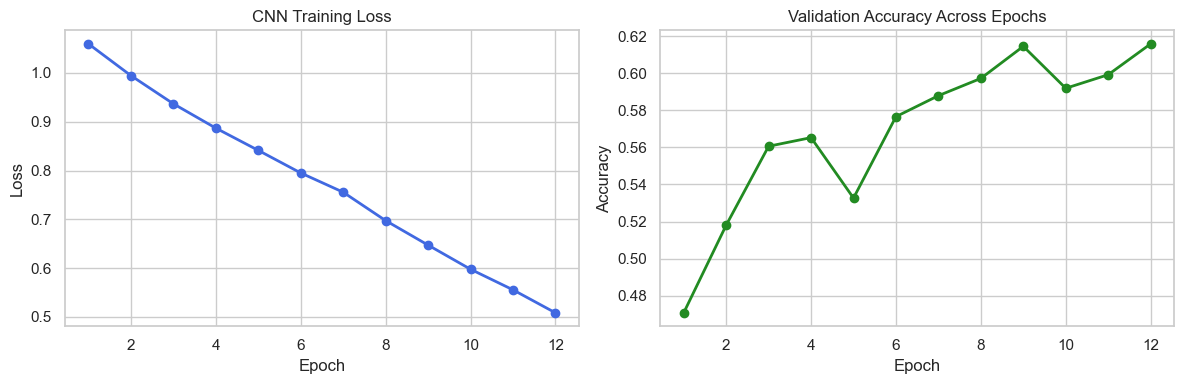

In [6]:
epochs = 12
train_losses = []
val_accuracies = []

print("Starting CNN training")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # validation accuracy after each epoch
    model.eval()
    val_preds_epoch = []
    val_labels_epoch = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            val_preds_epoch.extend(preds.cpu().numpy())
            val_labels_epoch.extend(labels.numpy())
            
    val_acc_epoch = accuracy_score(val_labels_epoch, val_preds_epoch)
    val_accuracies.append(val_acc_epoch)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Val Acc: {val_acc_epoch * 100:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, epochs + 1), train_losses, marker='o', color='royalblue', linewidth=2)
ax1.set_title('CNN Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(range(1, epochs + 1), val_accuracies, marker='o', color='forestgreen', linewidth=2)
ax2.set_title('Validation Accuracy Across Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

Test Set Accuracy: 63.73%
Test Majority-Class Baseline: 44.60%
Improvement over Test Baseline: 19.13 percentage points

Classification Report:
              precision    recall  f1-score   support

       Black       0.63      0.72      0.67       498
  Draw/Equal       0.50      0.17      0.26       333
       White       0.66      0.81      0.73       669

    accuracy                           0.64      1500
   macro avg       0.60      0.57      0.55      1500
weighted avg       0.62      0.64      0.60      1500



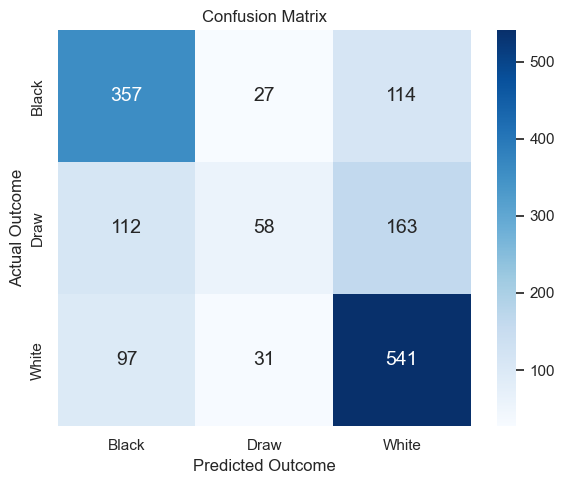

In [7]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Set Accuracy: {test_acc * 100:.2f}%")

test_majority_baseline = max(np.bincount(all_labels, minlength=3)) / len(all_labels)
print(f"Test Majority-Class Baseline: {test_majority_baseline * 100:.2f}%")
print(f"Improvement over Test Baseline: {(test_acc - test_majority_baseline) * 100:.2f} percentage points\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Black", "Draw/Equal", "White"], zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14}, xticklabels=["Black", "Draw", "White"], yticklabels=["Black", "Draw", "White"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.tight_layout()
plt.show()

### Training Behavior and Model Performance Interpretation

The training loss decreases steadily over epochs, which shows that CNN learned patterns from board tensor representation. Validation accuracy also improves over training and finishes around 61.60%, so model does not look like it is only memorizing training data.

The test accuracy is 63.73%, while test majority-class baseline is 44.60%. This gives improvement of 19.13 percentage points over simple baseline. The model is not perfect chess evaluator, but it performs clearly better than random guessing and better than baseline that always predicts most common class.

The classification report and confusion matrix show that model performs strongest on White-better and Black-better positions. White class has high recall, and Black class is also identified reasonably well. Draw/Equal is harder for the model, with lower recall. This makes sense because Draw/Equal positions are in the middle between the two advantage classes, and positions close to Stockfish threshold can be strategically similar.

For this project, this performance is acceptable. The CNN learned enough evaluation structure to be useful as model for explanation. Because of that, counterfactual analysis is not just testing random noise, but model decisions that came from learned chess patterns.

## 3. Baseline Explanation: Gradient Saliency

Before applying counterfactual explanations, we first compute simple gradient-based saliency map as baseline explanation method. This is included because project is about Explainable AI, and baseline method helps compare counterfactual explanations with more standard importance-based explanations.

The saliency map measures how sensitive predicted class score is to each input square. In this project, saliency values are summed across 13 tensor channels to create one 8x8 board-level importance map. This does not prove causality, but it gives first view of which board squares CNN is reacting to.

This baseline is useful because it answers different question from counterfactuals. Saliency asks: “Which squares influence model output?” Counterfactuals ask: “What actual change is enough to alter model output?”

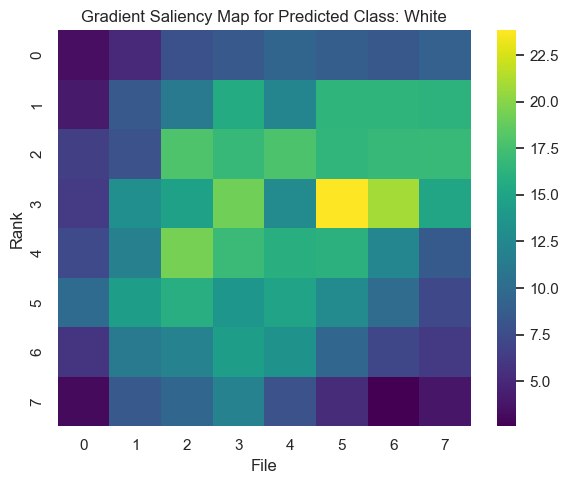

In [8]:
def compute_saliency_map(model, position_tensor, target_class=None):
    """
    Computes a simple gradient saliency map for one position.
    The output is an 8x8 heatmap summed over all input channels.
    """
    model.eval()
    
    x = position_tensor.unsqueeze(0).clone().detach().to(device)
    x.requires_grad_(True)
    
    output = model(x)
    
    if target_class is None:
        target_class = torch.argmax(output, dim=1).item()
        
    score = output[0, target_class]
    model.zero_grad()
    score.backward()
    
    # absolute gradient summed across channels
    saliency = x.grad.abs().detach().cpu().numpy()[0]
    board_saliency = saliency.sum(axis=0)
    
    return board_saliency, target_class

# select one example position from the test set
example_pos, example_label = test_dataset[0]
saliency_map, predicted_class = compute_saliency_map(model, example_pos)

plt.figure(figsize=(6, 5))
sns.heatmap(saliency_map, cmap="viridis")
plt.title(f"Gradient Saliency Map for Predicted Class: {class_map[predicted_class]}")
plt.xlabel("File")
plt.ylabel("Rank")
plt.tight_layout()
plt.show()

### Saliency Baseline Interpretation

The saliency map gives board-level view of where CNN is most sensitive for one selected position. Brighter squares mean that changes to those input locations would have larger local effect on predicted score.

However, this explanation is only local and gradient-based. A highlighted square does not always mean that changing this square will actually flip model prediction. This is why counterfactual explanations are useful in next section. They test whether a concrete intervention, such as removing one non-king piece, actually changes predicted class.

## 4. Counterfactual Explanation Method

The main explainability method in this project is counterfactual search. A counterfactual explanation tries to answer simple question: what minimal change to input would make model predict different class?

In the proposal, I described three possible levels of counterfactual generation:

- **Level 1:** remove one non-king piece.
- **Level 2:** relocate one piece to nearby empty square.
- **Level 3:** apply true legal-move counterfactuals.

For implemented experiment, I focus on **Level 1** counterfactuals. This is simplified version of original plan. I chose it because it is simple, interpretable, and directly connected to chess material value. Removing piece is not always legal chess move, so I treat it as intervention-based sensitivity test rather than fully realistic chess variation.

The method still follows main goal of proposal: it finds small perturbations that change predicted class, measures distance of these perturbations, and checks whether resulting explanations are stable across different model predictions.

In [9]:
# map channels to piece names and standard material values
channel_to_piece = {
    0: ('White Pawn', 1), 1: ('White Knight', 3), 2: ('White Bishop', 3),
    3: ('White Rook', 5), 4: ('White Queen', 9), 5: ('White King', 0),
    6: ('Black Pawn', 1), 7: ('Black Knight', 3), 8: ('Black Bishop', 3),
    9: ('Black Rook', 5), 10: ('Black Queen', 9), 11: ('Black King', 0)
}

# relaxed counterfactual method where removing a piece is not always a legal move
# it serves as an interventional test to probe the neural network boundary
def find_removal_counterfactuals(model, position_tensor, original_class):
    """
    Level 1 Counterfactual Search:
    Iteratively removes one piece from the board to check if the prediction flips.
    """
    cfs = []
    model.eval()
    with torch.no_grad():
        # iterate over the 12 piece channels
        for c in range(12):
            # kings are not removed because it breaks basic chess logic
            if c in [5, 11]:
                continue
                
            for i in range(8):
                for j in range(8):
                    if position_tensor[c, i, j].item() == 1:
                        cf_tensor = position_tensor.clone()
                        cf_tensor[c, i, j] = 0
                        
                        output = model(cf_tensor.unsqueeze(0))
                        probs = torch.softmax(output, dim=1)
                        new_class = torch.argmax(probs, dim=1).item()
                        new_confidence = probs[0, new_class].item()
                        
                        if new_class != original_class:
                            piece_name, val = channel_to_piece[c]
                            cfs.append({
                                'Change Type': 'Remove piece',
                                'Changed Piece': piece_name,
                                'Original Class': class_map[original_class],
                                'New Class': class_map[new_class],
                                'Changed Squares': 1,
                                'Material Distance': val,
                                'New Confidence': new_confidence
                            })
    return cfs

## 5. Counterfactual Experiments and Results

For counterfactual analysis, I sampled up to 500 test positions. This gives more stable estimate of flip rate and counterfactual distance than using only few examples. The counterfactual search is applied only to test data, so the explanations are checked on positions that model did not directly train on.

In [10]:
results_data = []
cf_distances = []

sample_n = min(500, len(test_dataset))
for idx in range(sample_n):
    pos, true_label = test_dataset[idx]
    pos = pos.to(device)
    
    model.eval()
    with torch.no_grad():
        orig_out = model(pos.unsqueeze(0))
        orig_probs = torch.softmax(orig_out, dim=1)
        orig_class = torch.argmax(orig_probs, dim=1).item()
        orig_confidence = orig_probs[0, orig_class].item()
    
    cfs = find_removal_counterfactuals(model, pos, orig_class)
    if cfs:
        # pick the counterfactual with the smallest material distance
        best_cf = sorted(cfs, key=lambda x: x['Material Distance'])[0]
        
        best_cf['Original Confidence'] = orig_confidence
        best_cf['Confidence Drop'] = orig_confidence - best_cf['New Confidence']
        
        results_data.append(best_cf)
        cf_distances.append(best_cf['Material Distance'])

# display the results in a formatted dataframe
cf_df = pd.DataFrame(results_data)

validity_rate = len(results_data) / sample_n
print(f"Counterfactual validity / flip rate: {validity_rate:.2%}\n")

display(cf_df.head(10))

Counterfactual validity / flip rate: 76.20%



,Change Type,Changed Piece,Original Class,New Class,Changed Squares,Material Distance,New Confidence,Original Confidence,Confidence Drop
0,Remove piece,White Pawn,White,Black,1,1,0.346582,0.709970,0.363388
1,Remove piece,White Bishop,White,Black,1,3,0.864887,0.922865,0.057978
2,Remove piece,White Pawn,White,Black,1,1,0.790146,0.496953,-0.293193
3,Remove piece,White Queen,White,Draw/Equal,1,9,0.343838,0.940154,0.596315
4,Remove piece,Black Bishop,Black,White,1,3,0.624810,0.936224,0.311415
5,Remove piece,Black Pawn,Black,White,1,1,0.619321,0.674539,0.055218
6,Remove piece,White Pawn,White,Black,1,1,0.411177,0.689553,0.278377
7,Remove piece,White Knight,White,Draw/Equal,1,3,0.479814,0.828532,0.348717
8,Remove piece,White Knight,White,Black,1,3,0.380660,0.912390,0.531731
9,Remove piece,White Pawn,White,Black,1,1,0.539353,0.531597,-0.007757


### Counterfactual Validity and Piece-Level Patterns

The flip rate is used as simple validity metric. Counterfactual is valid if intervention changes model prediction. In this experiment, method was able to find successful one-piece intervention for 76.20% of sampled test positions.

At first this looks like strong result because counterfactual search often finds valid examples. However, this result should be interpreted carefully. A very high flip rate also means that model predictions are fragile. In many cases, removing only one piece, often a pawn, was enough to move prediction to another class. A strong chess evaluator should not change its evaluation too easily after removal of low-value piece unless that piece is tactically or positionally critical.

Because of this, the high flip rate is not only evidence that counterfactual method works. It is also evidence that this CNN has unstable decision boundaries. This is consistent with model performance: the CNN performs above baseline, but it is still far from a strong chess engine. Therefore, counterfactuals are useful here because they reveal weakness of the trained model, not only its reasoning pattern.

By selecting smallest material-distance change for each position, this follows main idea of counterfactual explanation: finding small intervention that changes model output. In my run, most common counterfactual pieces were White pawns, Black pawns, bishops, queens, and knights. The top changes were White Pawn, Black Pawn, White Bishop, White Queen, and White Knight.

This does not mean that every pawn is decisive in real chess. Instead, it means that for this trained CNN, small pawn-level perturbations were often enough to cross learned boundary between classes. Counterfactual explanations therefore show model sensitivity that may not be obvious from accuracy alone.

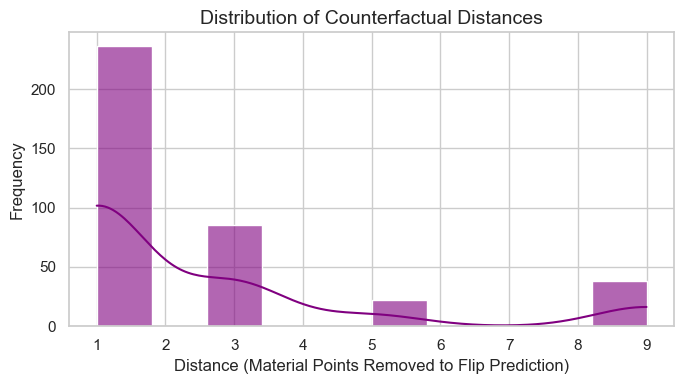

In [11]:
if cf_distances:
    plt.figure(figsize=(7, 4))
    sns.histplot(cf_distances, bins=10, kde=True, color='purple', alpha=0.6)
    plt.title('Distribution of Counterfactual Distances', fontsize=14)
    plt.xlabel('Distance (Material Points Removed to Flip Prediction)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No valid counterfactuals were found in the sampled subset.")

### Distance Distribution Interpretation

The distance distribution shows how large smallest successful intervention usually was. Smaller distances mean that prediction can be changed by removing low-value piece, while larger distances mean that model prediction is more resistant and needs larger material change.

In my run, distribution is mostly concentrated at 1 and 3 material points. There are also some larger-distance counterfactuals around 5 and 9 points, but they are less common. This supports idea that many model predictions are fragile under small local interventions. If model prediction changes after one-point material change, then learned decision boundary is close to original position.

## 6. Stability Analysis

One important part of reliable XAI method is explanation stability. Here, I check whether positions with same original predicted class need similar counterfactual changes to alter model prediction. This is not perfect measure of similar positions, but it gives simple way to see whether same type of model decision has similar counterfactual distance.

Most common counterfactual pieces (Top 5):



Changed Piece
White Pawn      144
Black Pawn       92
White Bishop     32
White Queen      25
White Knight     22
Name: count, dtype: int64

,Original Class,Avg_Distance,Most_Common_Change,Count,Stability Comment
0,Black,2.458333,Black Pawn,144,Less stable: small material changes often flip...
1,Draw/Equal,1.000000,White Pawn,43,Less stable: small material changes often flip...
2,White,2.814433,White Pawn,194,Less stable: small material changes often flip...


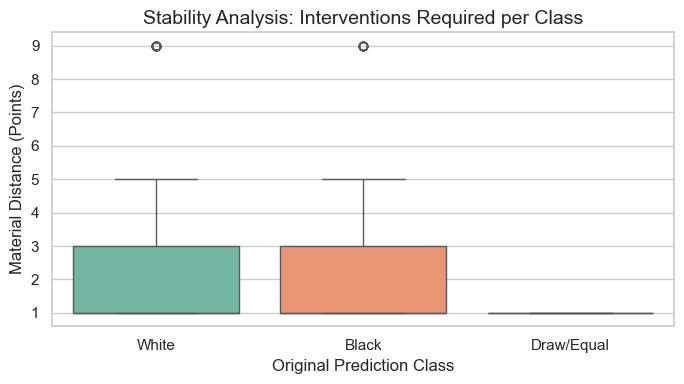

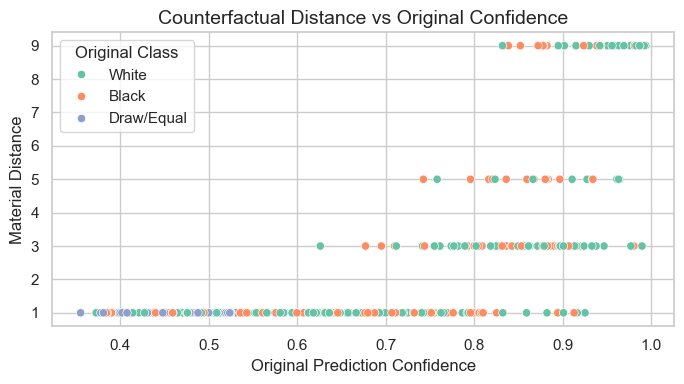

In [12]:
full_df = pd.DataFrame(results_data)

if not full_df.empty:
    print("Most common counterfactual pieces (Top 5):\n")
    display(full_df['Changed Piece'].value_counts().head(5))
    
    stability_summary = full_df.groupby('Original Class').agg(
        Avg_Distance=('Material Distance', 'mean'),
        Most_Common_Change=('Changed Piece', lambda x: x.mode()[0] if not x.empty else 'N/A'),
        Count=('Change Type', 'count')
    ).reset_index()
    
    def assess_stability(row):
        if row['Avg_Distance'] < 4:
            return "Less stable: small material changes often flip prediction"
        if row['Avg_Distance'] > 6:
            return "More stable: prediction usually requires large material change"
        return "Moderate stability: mixed dependency"
        
    stability_summary['Stability Comment'] = stability_summary.apply(assess_stability, axis=1)
    print("\n")
    display(stability_summary)
    
    # visualize stability via boxplot
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=full_df, x='Original Class', y='Material Distance', hue='Original Class', palette='Set2', legend=False)
    plt.title('Stability Analysis: Interventions Required per Class', fontsize=14)
    plt.xlabel('Original Prediction Class', fontsize=12)
    plt.ylabel('Material Distance (Points)', fontsize=12)
    plt.tight_layout()
    plt.show()

    if 'Original Confidence' in full_df.columns:
        plt.figure(figsize=(7, 4))
        sns.scatterplot(
            data=full_df,
            x='Original Confidence',
            y='Material Distance',
            hue='Original Class',
            palette='Set2'
        )
        plt.title('Counterfactual Distance vs Original Confidence', fontsize=14)
        plt.xlabel('Original Prediction Confidence', fontsize=12)
        plt.ylabel('Material Distance', fontsize=12)
        plt.tight_layout()
        plt.show()
else:
    print("Insufficient data")

### Stability Analysis Interpretation

The stability analysis groups counterfactuals by original predicted class. All three classes show low average counterfactual distances. Draw/Equal has lowest average distance, about 1.00, which means these predictions are very easy to flip when one valid counterfactual is found. Black has average distance around 2.46, and White has average distance around 2.81. These values are still low because they are below major-piece material values.

The number of valid counterfactuals is also different by class. In my run, White positions produced largest number of valid counterfactuals, then Black positions, while Draw/Equal produced fewer. This suggests that model boundary around White and Black predictions is often close enough that many one-piece removals can change prediction.

Overall, stability results show that explanations are valid, but not highly stable. Many predictions can be changed by small interventions, especially pawn removals. This is important finding because it suggests that CNN decision boundaries are relatively close to many test positions.

### Confidence-Based Stability

I also compare counterfactual distance with model original prediction confidence using scatterplot above. The plot shows that low-distance counterfactuals can happen across different confidence levels. This means model can sometimes be confident but still fragile under small input changes. Larger material-distance counterfactuals appear more often at higher confidence, but low-distance changes are still common.

## 7. Summary of Empirical Findings

| Component | Main Result | Interpretation |
|---|---|---|
| **Dataset** | 10,000 Lichess positions after 20 full moves | Realistic dataset for local XAI experiment |
| **Model** | Test accuracy = 63.73%, baseline = 44.60% | CNN learned meaningful but not perfect evaluation structure |
| **Baseline explanation** | Gradient saliency map | Shows local sensitivity over board squares |
| **Counterfactual validity** | Flip rate = 76.20% on 500 test positions | Many valid counterfactuals found, but also shows fragile model boundaries |
| **Distance metric** | Most counterfactuals have distance 1 or 3 | Model is sensitive to low-material changes |
| **Stability** | Average distances are low across classes | Predictions are not highly stable under small interventions |

Overall, table shows that model learned enough structure to be explained, but its decisions are still not fully stable. Accuracy is only first check. More important result for this project is that small counterfactual changes can often move prediction to another class.

## 8. Proposal Alignment and Comparison with Attribution Methods

This project follows original Project 2 proposal. In proposal, I planned to use Lichess chess positions, represent each position as 13x8x8 tensor, train neural network classifier, and analyze counterfactual explanations. The implemented project keeps this main structure. The main counterfactual method is one-piece removal, which matches proposed small piece modification idea. Distance is measured using material value and changed squares, while stability is checked by comparing counterfactual distances across predicted classes.

The main adjustment from proposal is that legal-move counterfactuals are treated as future work, not as main implemented method. I made this decision to keep experiment manageable and easier to interpret.

**Comparison with Project 1:**  
Project 1 focused on Feature Attribution. It asked *which parts* of board were connected to prediction, using methods like Saliency Maps and Grad-CAM to highlight important squares.

This project uses Counterfactual Intervention. It asks *what specific small change* can force model to predict different class.

Attribution methods tell us where model is looking, but counterfactuals test model boundary more directly. For example, attribution method may highlight defending knight. But counterfactual intervention gives stronger test: if removing that knight changes prediction, then model was sensitive to that piece in this specific position.

## 9. Limitations and Conclusion

One limitation of this project is that Level 1 counterfactuals do not follow full chess rules. Removing a piece is not legal chess move in real game, but it is still useful as sensitivity test for model.

Another limitation is that distance metric is based mostly on material value. This is easy to understand in chess terms, but it does not fully measure positional importance. For example, pawn near promotion or key defender can be more important than its basic material value.

In conclusion, this project analyzed chess position CNN using counterfactual explanations. The model was trained on Lichess positions represented as 13x8x8 tensors, with labels generated from Stockfish evaluations after 20 full moves. The CNN reached 63.73% test accuracy, which is clearly above 44.60% test majority-class baseline. This was enough to use it as model for explanation.

The baseline saliency map showed which board squares had high local gradient sensitivity, but it did not directly show whether changing those squares would alter prediction. Counterfactual explanations addressed this problem by testing concrete interventions. The main implemented method removed one non-king piece at a time and checked whether predicted class changed.

The main empirical finding is that many predictions were changed by low-distance interventions, especially pawn removals. The counterfactual flip rate was 76.20%, which means that one-piece removal often changed model output. This is useful for XAI because it gives many valid counterfactual examples, but it also shows important weakness of the CNN. The model is much more fragile than a real chess evaluator should be. In many positions, its prediction boundary is close enough that removing a low-value piece can move the model to another class. In other words, the CNN learned meaningful chess evaluation patterns, but its decisions are still not very stable. Counterfactual explanations are valuable here exactly because they expose this fragility. They show not only what the model may depend on, but also where the model is unreliable.

This project also shows why counterfactual explanations are useful in chess. A model may look like it relies on certain regions of board in saliency map, but counterfactuals test whether specific piece actually matters for final prediction. This makes counterfactuals more intervention-based than attribution methods. Future work could extend this project by using legal-move counterfactuals, relocation-based counterfactuals, larger training data, and more advanced CNN architecture.